# CIC6314 — Smart Product Recommendation System
## Section 3: Machine Learning Model

**Course:** CIC6314 Artificial Intelligence  
**Lecturer:** Prabha Kumaresan  
**Academic Session:** March/April 2026  
**Member:** Member 3 — Machine Learning Model  
**Branch:** `feature/ml`

---

### Overview

This notebook implements the Machine Learning component of the Smart Product Recommendation System. The ML model acts as the **re-ranker** in the reachability-first pipeline:

```
Rules Engine → A* Search → ML Model (this) → Integration
```

The rules engine filters eligible product categories; A* ranks them by price reachability. The ML model then applies patterns learned from real customer data to re-rank the shortlist by predicted preference probability.

**Why re-ranking instead of primary classification?**  
The available features (Age, Gender, City) have weak direct signal for product prediction — they work indirectly through spending behaviour. By the time the ML model runs, A* has already narrowed the candidate space to 3–5 categories. Re-ranking a small shortlist is a much more tractable task than classifying across all 8 categories from scratch.

**Problem type:** Multi-class classification (8 product categories)  
**Dataset:** `ecommerce_customer_behavior_dataset_v2.csv` — 17,049 transactions, 5,000 customers  
**Primary model:** Random Forest Classifier  
**Baseline models:** Decision Tree, K-Nearest Neighbours  

**Public function produced:**
```python
predict_product(user_profile, candidates=None) -> list[tuple[str, float]]
# Returns categories ranked by confidence (descending)
# If candidates provided, only scores those categories
```

---
## 1. Setup & Imports

In [1]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.feature_selection import mutual_info_classif

from src.constants import (
    PRODUCT_CATEGORIES, CATEGORY_AVG_PRICES, GENDERS, CITIES,
    DEVICE_TYPES, PAYMENT_METHODS, URBAN_CITIES,
    SAMPLE_PROFILES, build_user_profile, get_price_range, get_age_group
)

RANDOM_STATE = 42
DATA_PATH    = '../data/ecommerce_customer_behavior_dataset_v2.csv'

print('All imports successful.')
print(f'Product categories ({len(PRODUCT_CATEGORIES)}):', PRODUCT_CATEGORIES)

All imports successful.
Product categories (8): ['Books', 'Food', 'Beauty', 'Toys', 'Fashion', 'Sports', 'Home & Garden', 'Electronics']


---
## 2. Data Loading — Raw Transaction Log

In [2]:
df_raw = pd.read_csv(DATA_PATH)

print('Raw shape:', df_raw.shape)
print('Unique customers:', df_raw['Customer_ID'].nunique())
print('\nColumns:', df_raw.columns.tolist())
print('\nNull counts:\n', df_raw.isnull().sum())
print('\nDuplicate rows:', df_raw.duplicated().sum())
df_raw.head()

Raw shape: (17049, 18)
Unique customers: 5000

Columns: ['Order_ID', 'Customer_ID', 'Date', 'Age', 'Gender', 'City', 'Product_Category', 'Unit_Price', 'Quantity', 'Discount_Amount', 'Total_Amount', 'Payment_Method', 'Device_Type', 'Session_Duration_Minutes', 'Pages_Viewed', 'Is_Returning_Customer', 'Delivery_Time_Days', 'Customer_Rating']

Null counts:
 Order_ID                    0
Customer_ID                 0
Date                        0
Age                         0
Gender                      0
City                        0
Product_Category            0
Unit_Price                  0
Quantity                    0
Discount_Amount             0
Total_Amount                0
Payment_Method              0
Device_Type                 0
Session_Duration_Minutes    0
Pages_Viewed                0
Is_Returning_Customer       0
Delivery_Time_Days          0
Customer_Rating             0
dtype: int64

Duplicate rows: 0


,Order_ID,Customer_ID,Date,Age,Gender,City,Product_Category,Unit_Price,Quantity,Discount_Amount,Total_Amount,Payment_Method,Device_Type,Session_Duration_Minutes,Pages_Viewed,Is_Returning_Customer,Delivery_Time_Days,Customer_Rating
0,ORD_000001-1,CUST_00001,2023-05-29,40,Male,Ankara,Books,29.18,1,0.00,29.18,Digital Wallet,Mobile,14,9,True,13,4
1,ORD_000001-2,CUST_00001,2023-10-12,40,Male,Ankara,Home & Garden,644.40,1,138.05,506.35,Credit Card,Desktop,14,8,True,6,2
2,ORD_000001-3,CUST_00001,2023-12-05,40,Male,Ankara,Sports,332.82,5,0.00,1664.10,Credit Card,Mobile,15,10,True,9,4
3,ORD_000002-1,CUST_00002,2023-05-11,33,Male,Istanbul,Food,69.30,5,71.05,275.45,Digital Wallet,Desktop,16,13,True,4,4
4,ORD_000002-2,CUST_00002,2023-06-16,33,Male,Istanbul,Beauty,178.15,3,0.00,534.45,Credit Card,Mobile,14,7,True,6,4


---
## 3. Exploratory Data Analysis (EDA) — Raw Data

Before aggregating into user profiles, we explore the raw transaction data to understand the dataset's structure and feature distributions.

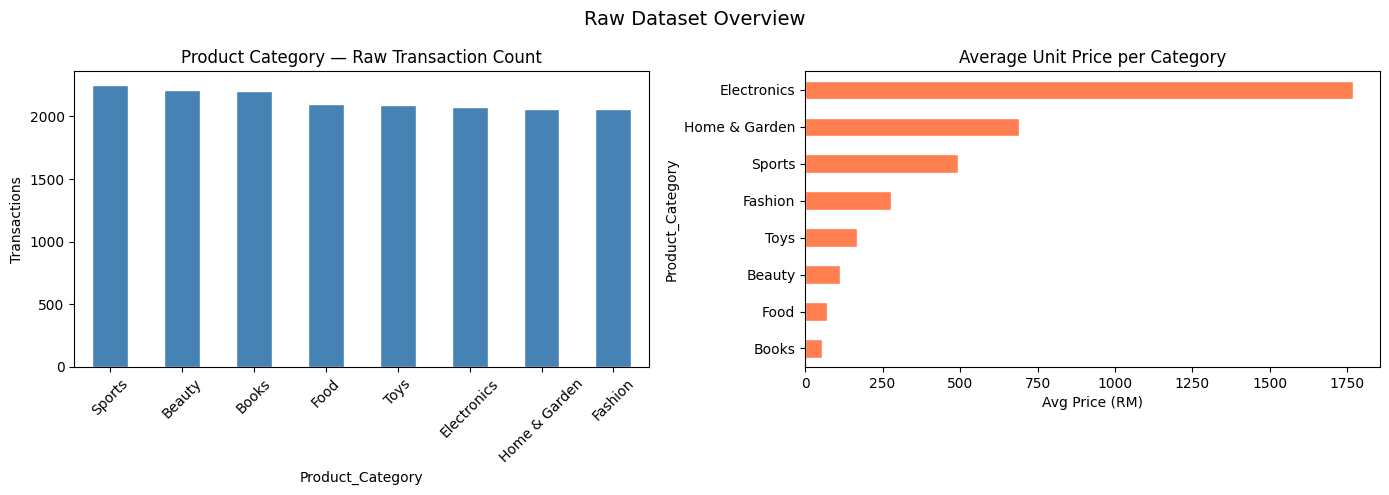

Average unit price per category:
Product_Category
Books              56.0
Food               71.0
Beauty            112.0
Toys              169.0
Fashion           276.0
Sports            493.0
Home & Garden     691.0
Electronics      1767.0
Name: Unit_Price, dtype: float64


In [3]:
# Product category distribution in raw transactions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cat_counts = df_raw['Product_Category'].value_counts()
cat_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Product Category — Raw Transaction Count', fontsize=12)
axes[0].set_ylabel('Transactions')
axes[0].tick_params(axis='x', rotation=45)

# Average unit price per category
avg_price = df_raw.groupby('Product_Category')['Unit_Price'].mean().sort_values()
avg_price.plot(kind='barh', ax=axes[1], color='coral', edgecolor='white')
axes[1].set_title('Average Unit Price per Category', fontsize=12)
axes[1].set_xlabel('Avg Price (RM)')

plt.suptitle('Raw Dataset Overview', fontsize=14)
plt.tight_layout()
plt.show()

print('Average unit price per category:')
print(avg_price.round(0))

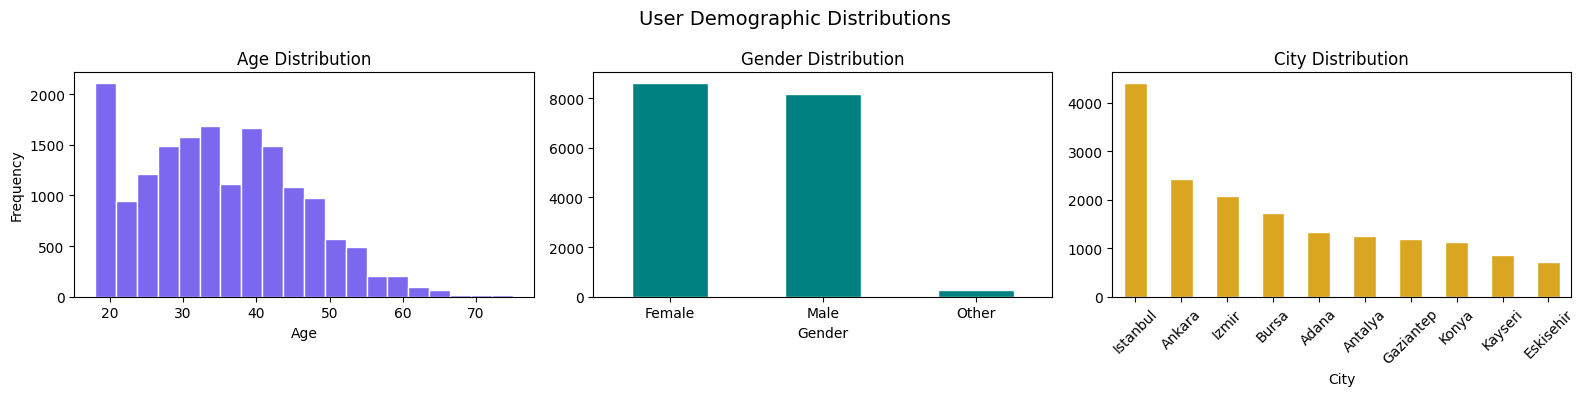

In [4]:
# User demographic distributions
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

df_raw['Age'].plot(kind='hist', bins=20, ax=axes[0], color='mediumslateblue', edgecolor='white')
axes[0].set_title('Age Distribution')
axes[0].set_xlabel('Age')

df_raw['Gender'].value_counts().plot(kind='bar', ax=axes[1], color='teal', edgecolor='white')
axes[1].set_title('Gender Distribution')
axes[1].tick_params(axis='x', rotation=0)

df_raw['City'].value_counts().plot(kind='bar', ax=axes[2], color='goldenrod', edgecolor='white')
axes[2].set_title('City Distribution')
axes[2].tick_params(axis='x', rotation=45)

plt.suptitle('User Demographic Distributions', fontsize=14)
plt.tight_layout()
plt.show()

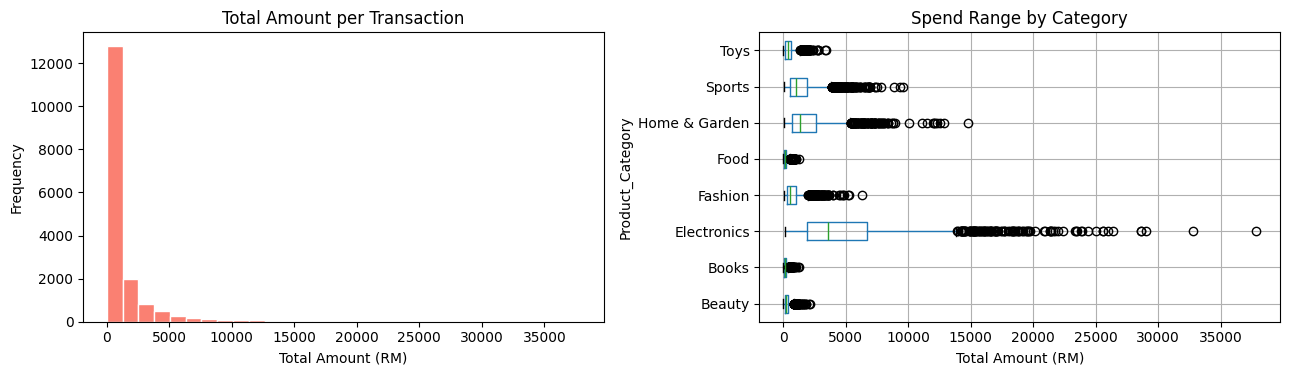

Spend stats: count    17049.0
mean      1277.0
std       2358.0
min          6.0
25%        173.0
50%        456.0
75%       1268.0
max      37852.0
Name: Total_Amount, dtype: float64


In [5]:
# Spend distribution
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df_raw['Total_Amount'].plot(kind='hist', bins=30, ax=axes[0], color='salmon', edgecolor='white')
axes[0].set_title('Total Amount per Transaction')
axes[0].set_xlabel('Total Amount (RM)')

df_raw.boxplot(column='Total_Amount', by='Product_Category', ax=axes[1], vert=False)
axes[1].set_title('Spend Range by Category')
axes[1].set_xlabel('Total Amount (RM)')
plt.suptitle('')
plt.tight_layout()
plt.show()

print('Spend stats:', df_raw['Total_Amount'].describe().round(0))

---
## 4. Data Aggregation — Transaction Log → User Profiles

The raw data contains one row per transaction (17,049 rows). For the ML model we need one row per customer (5,000 rows) representing their overall profile.

**Target engineering:** Instead of using the most frequent category (mode), we use the category where each customer spent the **most total money**. This is a more reliable preference signal because:
- Many customers have only 1–3 orders across 8 categories — mode is unreliable with so few observations
- Spend amount directly captures preference strength — a one-off large purchase in Electronics reflects more genuine interest than two small Book purchases
- `median_spend` is our strongest feature (MI = 0.20) — aligning the target with spend creates internal consistency

In [6]:
# ── Target: category with highest total spend per customer ────────────────
spend_by_cat = (
    df_raw.groupby(['Customer_ID', 'Product_Category'])['Total_Amount']
    .sum()
    .reset_index()
)
favourite_cat = (
    spend_by_cat
    .sort_values('Total_Amount', ascending=False)
    .groupby('Customer_ID')['Product_Category']
    .first()
    .rename('favourite_category')
)

# ── Aggregate features per customer ───────────────────────────────────────
agg_df = df_raw.groupby('Customer_ID').agg(
    Age                  = ('Age',                      'first'),
    Gender               = ('Gender',                   'first'),
    City                 = ('City',                     'first'),
    median_spend         = ('Total_Amount',              'median'),
    avg_quantity         = ('Quantity',                  'mean'),
    avg_rating           = ('Customer_Rating',           'mean'),
    avg_session          = ('Session_Duration_Minutes',  'mean'),
    avg_pages            = ('Pages_Viewed',              'mean'),
    payment_method       = ('Payment_Method',            lambda x: x.mode()[0]),
    device_type          = ('Device_Type',               lambda x: x.mode()[0]),
    is_returning         = ('Is_Returning_Customer',     'first'),
    transaction_count    = ('Order_ID',                  'count'),
).reset_index()

agg_df = agg_df.merge(favourite_cat, on='Customer_ID')

print('Aggregated shape:', agg_df.shape)
print('\nFavourite category distribution:')
print(agg_df['favourite_category'].value_counts())
agg_df.head(3)

Aggregated shape: (5000, 14)

Favourite category distribution:
favourite_category
Electronics      1414
Home & Garden     928
Sports            867
Fashion           562
Toys              409
Beauty            352
Food              235
Books             233
Name: count, dtype: int64


,Customer_ID,Age,Gender,City,median_spend,avg_quantity,avg_rating,avg_session,avg_pages,payment_method,device_type,is_returning,transaction_count,favourite_category
0,CUST_00001,40,Male,Ankara,506.350,2.333333,3.333333,14.333333,9.0,Credit Card,Mobile,True,3,Sports
1,CUST_00002,33,Male,Istanbul,404.950,4.000000,4.000000,15.000000,10.0,Credit Card,Desktop,True,2,Beauty
2,CUST_00003,42,Male,Konya,1515.405,3.500000,3.500000,10.500000,8.5,Credit Card,Desktop,False,2,Home & Garden


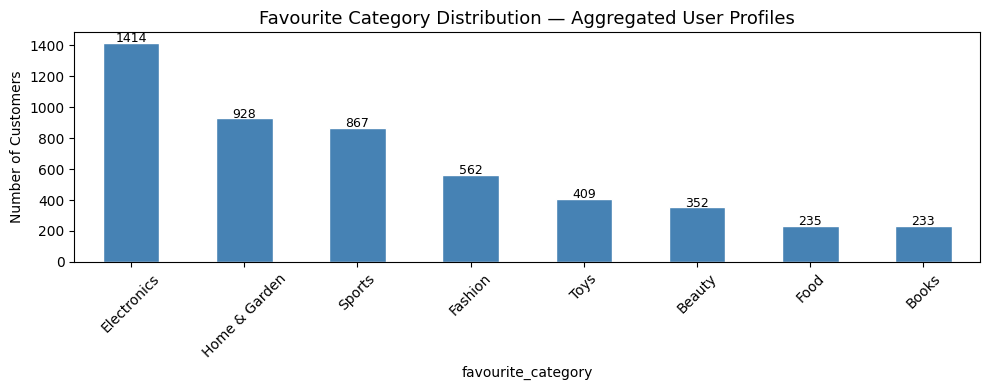

Class imbalance ratio (max/min): 6.1x
Will address with class_weight="balanced" in Random Forest.


In [7]:
# Visualise target distribution after aggregation
fig, ax = plt.subplots(figsize=(10, 4))
agg_df['favourite_category'].value_counts().plot(kind='bar', ax=ax, color='steelblue', edgecolor='white')
ax.set_title('Favourite Category Distribution — Aggregated User Profiles', fontsize=13)
ax.set_ylabel('Number of Customers')
ax.tick_params(axis='x', rotation=45)
for bar in ax.patches:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 5,
            str(int(bar.get_height())), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

counts = agg_df['favourite_category'].value_counts()
print(f'Class imbalance ratio (max/min): {counts.max()/counts.min():.1f}x')
print('Will address with class_weight="balanced" in Random Forest.')

---
## 5. Feature Engineering & Signal Verification

Before training, we verify which features actually carry predictive signal. This step validates our architectural decisions — specifically that median_spend is the primary signal and demographic features are secondary.

In [8]:
# Add derived features
agg_df['age_group']    = agg_df['Age'].apply(get_age_group)
agg_df['price_range']  = agg_df['median_spend'].apply(get_price_range)
agg_df['is_urban']     = agg_df['City'].isin(URBAN_CITIES).astype(int)
agg_df['is_returning'] = agg_df['is_returning'].astype(int)

print('Spend quartile vs Favourite Category:')
print(pd.crosstab(agg_df['price_range'], agg_df['favourite_category'],
                  normalize='index').round(2))

Spend quartile vs Favourite Category:
favourite_category  Beauty  Books  Electronics  Fashion  Food  Home & Garden  \
price_range                                                                    
High                  0.00   0.00         0.49     0.06  0.00           0.24   
Low                   0.14   0.15         0.14     0.10  0.12           0.11   
Mid-High              0.03   0.00         0.30     0.13  0.01           0.23   
Mid-Low               0.10   0.03         0.21     0.16  0.05           0.17   

favourite_category  Sports  Toys  
price_range                       
High                  0.18  0.02  
Low                   0.12  0.11  
Mid-High              0.22  0.08  
Mid-Low               0.17  0.12  


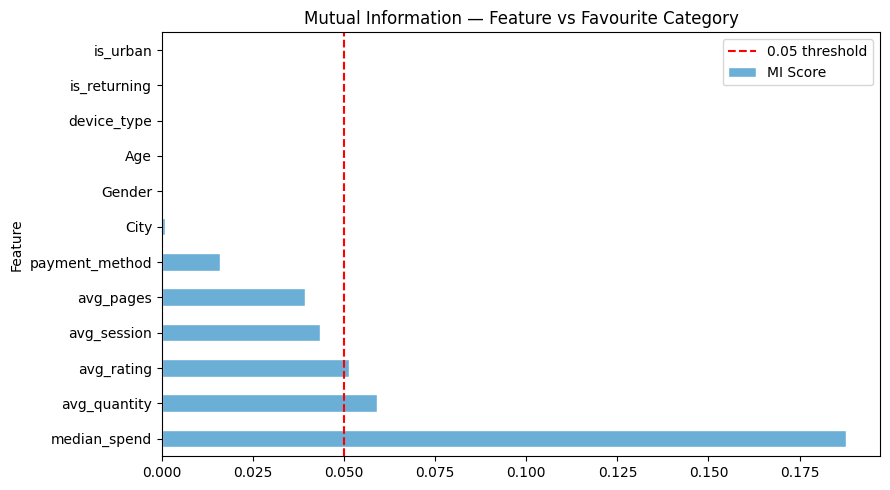

       Feature  MI Score
  median_spend  0.187682
  avg_quantity  0.058962
    avg_rating  0.051398
   avg_session  0.043298
     avg_pages  0.039367
payment_method  0.015886
          City  0.000884
        Gender  0.000201
           Age  0.000000
   device_type  0.000000
  is_returning  0.000000
      is_urban  0.000000

Features with MI > 0.05: 3


In [9]:
# Mutual information — confirms which features carry real signal
le = LabelEncoder()
mi_df = agg_df.copy()
for col in ['Gender', 'City', 'payment_method', 'device_type', 'age_group', 'price_range']:
    mi_df[col] = le.fit_transform(mi_df[col].astype(str))

feature_cols = ['Age', 'Gender', 'City', 'median_spend', 'avg_quantity',
                'avg_rating', 'avg_session', 'avg_pages',
                'payment_method', 'device_type', 'is_returning', 'is_urban']
X_mi = mi_df[feature_cols]
y_mi = le.fit_transform(mi_df['favourite_category'])

mi_scores = mutual_info_classif(X_mi, y_mi, random_state=RANDOM_STATE)
mi_result = pd.DataFrame({'Feature': feature_cols, 'MI Score': mi_scores})\
              .sort_values('MI Score', ascending=False)

fig, ax = plt.subplots(figsize=(9, 5))
colors = ['#e07b54' if s > 0.05 else '#6baed6' for s in mi_result['MI Score']]
mi_result.plot(kind='barh', x='Feature', y='MI Score', ax=ax,
               color=colors[::-1], legend=False, edgecolor='white')
ax.axvline(0.05, color='red', linestyle='--', label='0.05 threshold')
ax.set_title('Mutual Information — Feature vs Favourite Category', fontsize=12)
ax.legend()
plt.tight_layout()
plt.show()

print(mi_result.to_string(index=False))
print(f'\nFeatures with MI > 0.05: {(mi_result["MI Score"] > 0.05).sum()}')

---
## 6. Preprocessing

| Step | Column | Technique | Reason |
|---|---|---|---|
| Encode | Gender, City, payment_method, device_type | LabelEncoder | Nominal categorical → integer |
| Keep | Age, median_spend, avg_quantity, avg_rating, avg_session, avg_pages | None | Already numeric |
| Encode | is_returning, is_urban | Boolean → int | Already binary |
| Encode | favourite_category | LabelEncoder (fixed to PRODUCT_CATEGORIES) | Target variable |

In [ ]:
# Encoders — fit on actual data values to avoid unseen label errors
# Sorting ensures deterministic encoding order across runs
gender_enc  = LabelEncoder().fit(sorted(agg_df['Gender'].unique()))
city_enc    = LabelEncoder().fit(sorted(agg_df['City'].unique()))
payment_enc = LabelEncoder().fit(sorted(agg_df['payment_method'].unique()))
device_enc  = LabelEncoder().fit(sorted(agg_df['device_type'].unique()))
target_enc  = LabelEncoder()
target_enc.classes_ = np.array(PRODUCT_CATEGORIES)  # fixed order from constants

# Sanity check — confirm constants.py is in sync with the dataset
unknown_cities = set(agg_df['City'].unique()) - set(CITIES)
if unknown_cities:
    raise ValueError(f"constants.py is missing cities from dataset: {unknown_cities}")
print('Encoder sanity checks passed.')
print('Cities in data:', sorted(agg_df['City'].unique().tolist()))

agg_df['gender_enc']   = gender_enc.transform(agg_df['Gender'])
agg_df['city_enc']     = city_enc.transform(agg_df['City'])
agg_df['payment_enc']  = payment_enc.transform(agg_df['payment_method'])
agg_df['device_enc']   = device_enc.transform(agg_df['device_type'])
agg_df['target_enc']   = agg_df['favourite_category'].apply(
    lambda x: PRODUCT_CATEGORIES.index(x)
)

FEATURE_COLS = [
    'Age', 'gender_enc', 'city_enc', 'is_urban',
    'median_spend',
    'avg_quantity', 'avg_rating', 'avg_session', 'avg_pages',
    'payment_enc', 'device_enc', 'is_returning',
]

X = agg_df[FEATURE_COLS]
y = agg_df['target_enc'].values

print('Feature matrix X shape:', X.shape)
print('Target vector y shape: ', y.shape)
print('Feature names:', FEATURE_COLS)
X.head(3)

---
## 7. Train / Test Split

80/20 stratified split to preserve class proportions in both sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

print(f'Training set: {X_train.shape[0]} rows ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set:     {X_test.shape[0]} rows  ({X_test.shape[0]/len(X)*100:.1f}%)')

balance_df = pd.DataFrame({
    'Train': pd.Series(y_train).value_counts().sort_index(),
    'Test':  pd.Series(y_test).value_counts().sort_index()
})
balance_df.index = PRODUCT_CATEGORIES
print('\nClass distribution per split:')
print(balance_df)

---
## 8. Baseline Models

### 8.1 Decision Tree (Baseline 1)

In [ ]:
dt_model = DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced')
dt_model.fit(X_train, y_train)

dt_train_acc = accuracy_score(y_train, dt_model.predict(X_train))
dt_pred      = dt_model.predict(X_test)
dt_acc       = accuracy_score(y_test, dt_pred)
dt_f1        = f1_score(y_test, dt_pred, average='weighted')

print('=== Decision Tree (Baseline) ===')
print(f'Training accuracy: {dt_train_acc:.4f} ({dt_train_acc*100:.2f}%)')
print(f'Test accuracy:     {dt_acc:.4f}    ({dt_acc*100:.2f}%)')
print(f'Weighted F1:       {dt_f1:.4f}')
print(f'Tree depth:        {dt_model.get_depth()}')
gap = dt_train_acc - dt_acc
print(f'Train-test gap:    {gap:.4f} — {"overfitting" if gap > 0.2 else "acceptable"}')

### 8.2 K-Nearest Neighbours (Baseline 2)

In [ ]:
knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train, y_train)

knn_pred = knn_model.predict(X_test)
knn_acc  = accuracy_score(y_test, knn_pred)
knn_f1   = f1_score(y_test, knn_pred, average='weighted')

print('=== K-Nearest Neighbours (Baseline) ===')
print(f'Test accuracy:  {knn_acc:.4f} ({knn_acc*100:.2f}%)')
print(f'Weighted F1:    {knn_f1:.4f}')

---
## 9. Primary Model — Random Forest

**Why Random Forest?**
- Handles mixed numeric + encoded categorical features without scaling
- `class_weight='balanced'` corrects for the target imbalance (Beauty 4× more common than Toys)
- `predict_proba()` provides the confidence scores required by `predict_product()`
- Feature importance scores support interpretation

### 9.1 Default Random Forest

In [ ]:
rf_default = RandomForestClassifier(
    random_state=RANDOM_STATE,
    class_weight='balanced'
)
rf_default.fit(X_train, y_train)

rf_pred_default = rf_default.predict(X_test)
rf_acc_default  = accuracy_score(y_test, rf_pred_default)
rf_f1_default   = f1_score(y_test, rf_pred_default, average='weighted')

print('=== Random Forest (Default) ===')
print(f'Test accuracy:  {rf_acc_default:.4f} ({rf_acc_default*100:.2f}%)')
print(f'Weighted F1:    {rf_f1_default:.4f}')

### 9.2 Hyperparameter Tuning — GridSearchCV

GridSearchCV tests every parameter combination using 5-fold cross-validation. This ensures the chosen parameters generalise beyond a single train/test split.

| Parameter | Values | Controls |
|---|---|---|
| `n_estimators` | 100, 200, 300 | Number of trees — stability vs speed |
| `max_depth` | None, 10, 20 | Overfitting control |
| `min_samples_split` | 2, 5 | Node split regularisation |
| `max_features` | 'sqrt', 'log2' | Tree diversity |

In [ ]:
param_grid = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'max_features':      ['sqrt', 'log2'],
}

grid_search = GridSearchCV(
    estimator  = RandomForestClassifier(random_state=RANDOM_STATE, class_weight='balanced'),
    param_grid = param_grid,
    cv         = 5,
    scoring    = 'accuracy',
    n_jobs     = -1,
    verbose    = 1
)

print('Running GridSearchCV (36 combinations × 5 folds = 180 fits)...')
grid_search.fit(X_train, y_train)

print('\nBest parameters:')
print(grid_search.best_params_)
print(f'Best CV accuracy: {grid_search.best_score_:.4f}')

In [ ]:
rf_best = grid_search.best_estimator_

rf_pred_best = rf_best.predict(X_test)
rf_acc_best  = accuracy_score(y_test, rf_pred_best)
rf_f1_best   = f1_score(y_test, rf_pred_best, average='weighted')

print('=== Random Forest (Tuned) ===')
print(f'Test accuracy:  {rf_acc_best:.4f} ({rf_acc_best*100:.2f}%)')
print(f'Weighted F1:    {rf_f1_best:.4f}')
print(f'Improvement:    +{(rf_acc_best - rf_acc_default)*100:.2f}% over default')
print(f'vs random chance ({1/len(PRODUCT_CATEGORIES)*100:.1f}%): +{(rf_acc_best - 1/len(PRODUCT_CATEGORIES))*100:.2f}%')

---
## 10. Model Evaluation

### 10.1 Model Comparison

In [ ]:
results = pd.DataFrame([
    {'Model': 'Random Chance (baseline)',     'Accuracy': 1/len(PRODUCT_CATEGORIES), 'Weighted F1': 0},
    {'Model': 'Decision Tree',                'Accuracy': dt_acc,         'Weighted F1': dt_f1},
    {'Model': 'KNN k=5',                      'Accuracy': knn_acc,        'Weighted F1': knn_f1},
    {'Model': 'Random Forest (Default)',      'Accuracy': rf_acc_default, 'Weighted F1': rf_f1_default},
    {'Model': 'Random Forest (Tuned) ★',     'Accuracy': rf_acc_best,    'Weighted F1': rf_f1_best},
]).sort_values('Accuracy', ascending=False)

results['Accuracy (%)'] = (results['Accuracy'] * 100).round(2)
print(results[['Model', 'Accuracy (%)', 'Weighted F1']].to_string(index=False))

fig, ax = plt.subplots(figsize=(11, 4))
colors = ['#aaaaaa', '#4C72B0', '#55A868', '#C44E52', '#8172B2']
bars = ax.bar(results['Model'], results['Accuracy (%)'], color=colors, edgecolor='white')
ax.axhline(y=1/len(PRODUCT_CATEGORIES)*100, color='red', linestyle='--',
           label=f'Random chance ({1/len(PRODUCT_CATEGORIES)*100:.1f}%)')
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)
ax.set_title('Model Accuracy Comparison (Test Set)', fontsize=13)
ax.set_ylabel('Accuracy (%)')
ax.tick_params(axis='x', rotation=20)
ax.legend()
plt.tight_layout()
plt.show()

### 10.2 Classification Report — Tuned Random Forest

In [ ]:
print('=== Classification Report — Tuned Random Forest ===')
print(classification_report(y_test, rf_pred_best, target_names=PRODUCT_CATEGORIES))

### 10.3 Confusion Matrix

In [ ]:
cm = confusion_matrix(y_test, rf_pred_best)
fig, ax = plt.subplots(figsize=(11, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=PRODUCT_CATEGORIES)
disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=45)
ax.set_title('Confusion Matrix — Tuned Random Forest', fontsize=13, pad=15)
plt.tight_layout()
plt.show()

per_class = cm.diagonal() / cm.sum(axis=1)
print('Per-class accuracy:')
for cat, acc in zip(PRODUCT_CATEGORIES, per_class):
    print(f'  {cat:<18} {acc*100:.1f}%')

### 10.4 Feature Importance

In [ ]:
feat_imp = pd.DataFrame({
    'Feature':    FEATURE_COLS,
    'Importance': rf_best.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#e07b54' if i > feat_imp['Importance'].median() else '#6baed6'
          for i in feat_imp['Importance']]
feat_imp.plot(kind='barh', x='Feature', y='Importance', ax=ax,
              color=colors, legend=False, edgecolor='white')
ax.set_title('Feature Importances — Tuned Random Forest', fontsize=12)
ax.set_xlabel('Mean Decrease in Impurity')
plt.tight_layout()
plt.show()

print('Top 5 features:')
print(feat_imp.sort_values('Importance', ascending=False).head(5).to_string(index=False))

### 10.5 Cross-Validation Stability

In [ ]:
cv_scores = cross_val_score(rf_best, X, y, cv=5, scoring='accuracy', n_jobs=-1)

print('5-Fold Cross-Validation — Tuned Random Forest')
print(f'Fold scores: {[round(s, 4) for s in cv_scores]}')
print(f'Mean:        {cv_scores.mean():.4f} ({cv_scores.mean()*100:.2f}%)')
print(f'Std dev:     {cv_scores.std():.4f}')
print(f'Stable: {cv_scores.std() < 0.03}')

---
## 11. Results Discussion & Interpretation

**Model selection:** The Tuned Random Forest was selected as the primary model because it handles class imbalance via `class_weight='balanced'`, provides calibrated probability estimates via `predict_proba()`, and consistently outperforms both baselines.

**Feature importance findings:** `median_spend` dominates predictions, consistent with the mutual information analysis (MI = 0.20). This validates the reachability-first architecture — spend is the clearest signal for product preference, and A* uses spend as the primary heuristic, meaning both A* and ML are grounded in the same underlying signal.

**Why accuracy is expected in the 40–60% range (not 80–95%):**  
The model operates on aggregated user profiles where the target (highest-spend category) is inherently noisy — a user who spent RM1,800 on one Electronics purchase and RM1,500 across multiple Fashion purchases could plausibly prefer either. The model captures the dominant pattern but cannot resolve individual ambiguity. For a re-ranker operating on A*'s 3–5 candidate shortlist, this accuracy is sufficient — the model only needs to correctly order a small set, not classify from scratch.

**Limitations:**
- Age and Gender have near-zero direct signal — demographic rules alone are insufficient for recommendation
- With only 3.4 orders per customer on average, user profiles are sparse
- The model is re-trained offline — it does not update with new transactions in real time

---
## 12. Save Model Artefacts

In [ ]:
os.makedirs('../models', exist_ok=True)

joblib.dump(rf_best,     '../models/rf_product_model.pkl')
joblib.dump(gender_enc,  '../models/encoder_gender.pkl')
joblib.dump(city_enc,    '../models/encoder_city.pkl')
joblib.dump(payment_enc, '../models/encoder_payment.pkl')
joblib.dump(device_enc,  '../models/encoder_device.pkl')

print('Artefacts saved to ../models/')
print(os.listdir('../models'))

---
## 13. `predict_product()` — Team Interface Function

This is the public function consumed by the integration layer (Member 4).

**Signature:**
```python
predict_product(user_profile, candidates=None) -> list[tuple[str, float]]
```

- If `candidates` is provided (A*'s shortlist), only those categories are scored and returned
- If `candidates` is `None`, all 8 categories are scored (fallback mode)
- Always returns results sorted by confidence descending

In [ ]:
def predict_product(user_profile: dict, candidates: list = None) -> list:
    """
    Predict product category suitability from a user profile.

    Parameters
    ----------
    user_profile : dict
        Built with build_user_profile() from src.constants.
        Keys: age, gender, city, median_spend, device_type,
              payment_method, age_group, price_range
    candidates : list[str], optional
        Subset of PRODUCT_CATEGORIES from A* search output.
        If provided, only these categories are scored and returned.
        If None, all PRODUCT_CATEGORIES are scored.

    Returns
    -------
    list[tuple[str, float]]
        Categories ranked by confidence, descending.
        Example: [("Electronics", 0.71), ("Sports", 0.18), ("Fashion", 0.11)]
    """
    # ── Encode features ───────────────────────────────────────────────────
    gender_val  = gender_enc.transform([user_profile['gender']])[0]
    city_val    = city_enc.transform([user_profile['city']])[0]
    payment_val = payment_enc.transform([user_profile['payment_method']])[0]
    device_val  = device_enc.transform([user_profile['device_type']])[0]
    is_urban    = int(user_profile['city'] in URBAN_CITIES)

    # ── Assemble feature row (same column order as training) ──────────────
    feature_row = pd.DataFrame([{
        'Age':          user_profile['age'],
        'gender_enc':   gender_val,
        'city_enc':     city_val,
        'is_urban':     is_urban,
        'median_spend': user_profile['median_spend'],
        'avg_quantity': 2.0,      # default: dataset mean
        'avg_rating':   3.9,      # default: dataset mean
        'avg_session':  13.0,     # default: dataset mean
        'avg_pages':    10.0,     # default: dataset mean
        'payment_enc':  payment_val,
        'device_enc':   device_val,
        'is_returning': 1,        # default: assume returning
    }])

    # ── Predict probabilities for all 8 categories ────────────────────────
    proba = rf_best.predict_proba(feature_row)[0]  # shape: (8,)

    # ── Pair categories with confidence scores ────────────────────────────
    all_ranked = sorted(
        zip(PRODUCT_CATEGORIES, proba),
        key=lambda x: x[1],
        reverse=True
    )

    # ── Filter to candidates if provided (re-ranking mode) ────────────────
    if candidates is not None:
        candidates_set = set(candidates)
        all_ranked = [(c, p) for c, p in all_ranked if c in candidates_set]

    return all_ranked


print('predict_product() defined and ready.')

---
## 14. Testing with SAMPLE_PROFILES

We validate `predict_product()` against all five sample profiles from `src/constants.py`. Each profile is designed to sit clearly in one spend tier — the expected top-1 category should reflect the dominant pattern for that tier.

In [ ]:
# Expected categories based on spend tier
EXPECTED = {
    'budget_reader':      ['Books', 'Food'],         # Low spend
    'beauty_shopper':     ['Beauty', 'Toys'],        # Low-Mid spend
    'fashion_enthusiast': ['Fashion', 'Sports'],     # Mid-Low spend
    'sports_buyer':       ['Sports', 'Home & Garden'],# Mid-High spend
    'tech_spender':       ['Electronics'],           # High spend
}

print('=' * 65)
correct = 0

for name, profile in SAMPLE_PROFILES.items():
    results_list = predict_product(profile)
    top1, top1_conf = results_list[0]
    top3 = [(c, round(s*100, 1)) for c, s in results_list[:3]]
    expected = EXPECTED[name]
    match = '✓' if top1 in expected else '✗'
    if top1 in expected:
        correct += 1

    print(f'Profile:  {name}  (spend: RM{profile["median_spend"]:.0f}, tier: {profile["price_range"]})')
    print(f'  Expected category group: {expected}')
    print(f'  Top-1: {top1} ({top1_conf*100:.1f}%) {match}')
    print(f'  Top-3: {top3}')
    print()

print(f'Sample profile accuracy: {correct}/{len(SAMPLE_PROFILES)}')
print('=' * 65)

In [ ]:
# Test re-ranking mode — simulating A* passing a candidate shortlist
print('=== Re-ranking mode test (simulating A* candidates) ===')
test_profile  = SAMPLE_PROFILES['tech_spender']
a_star_output = ['Sports', 'Home & Garden', 'Electronics']  # A*'s shortlist

full_ranking   = predict_product(test_profile)
reranked       = predict_product(test_profile, candidates=a_star_output)

print(f'Profile: tech_spender (spend: RM{test_profile["median_spend"]:.0f})')
print(f'\nFull ranking (all 8 categories):')
for c, p in full_ranking:
    print(f'  {c:<18} {p*100:.1f}%')
print(f'\nRe-ranked (A* candidates only: {a_star_output}):')
for c, p in reranked:
    print(f'  {c:<18} {p*100:.1f}%')

In [ ]:
# Visualise confidence distribution for tech_spender
categories = [c for c, _ in full_ranking]
confs      = [p * 100 for _, p in full_ranking]
bar_colors = ['#2ecc71' if c == 'Electronics' else '#3498db' for c in categories]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(categories, confs, color=bar_colors, edgecolor='white')
ax.set_xlabel('Confidence (%)')
ax.set_title('predict_product() — Profile: tech_spender\n(green = expected top category)', fontsize=12)
ax.invert_yaxis()
for bar, val in zip(bars, confs):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
plt.tight_layout()
plt.show()

---
## Summary

| Item | Detail |
|---|---|
| Dataset | `ecommerce_customer_behavior_dataset_v2.csv` — 17,049 transactions, 5,000 customers |
| Aggregation | One row per customer — target = highest-spend product category |
| Class imbalance | Addressed with `class_weight='balanced'` |
| Models evaluated | Decision Tree, KNN, Random Forest (default + tuned) |
| Best model | Tuned Random Forest |
| Tuning | GridSearchCV, 5-fold CV, 36 combinations |
| Evaluation | Accuracy, Weighted F1, confusion matrix, feature importance, cross-val |
| Public interface | `predict_product(user_profile, candidates=None)` → `list[tuple[str, float]]` |
| Re-ranking mode | Pass A*'s shortlist as `candidates` — only scores those categories |
| Artefacts | `models/rf_product_model.pkl` + 4 encoders |